Loading dataset...

Dataset loaded successfully.
Shape: (4237907, 11)

Columns:
['time', 'channel1', 'channel2', 'channel3', 'channel4', 'channel5', 'channel6', 'channel7', 'channel8', 'class', 'label']

First 5 rows:
   time  channel1  channel2  channel3  channel4  channel5  channel6  channel7  \
0     1   0.00001  -0.00002  -0.00001  -0.00003   0.00000  -0.00001   0.00000   
1     5   0.00001  -0.00002  -0.00001  -0.00003   0.00000  -0.00001   0.00000   
2     6  -0.00001   0.00001   0.00002   0.00000   0.00001  -0.00002  -0.00001   
3     7  -0.00001   0.00001   0.00002   0.00000   0.00001  -0.00002  -0.00001   
4     8  -0.00001   0.00001   0.00002   0.00000   0.00001  -0.00002  -0.00001   

   channel8  class  label  
0  -0.00001      0      1  
1  -0.00001      0      1  
2   0.00001      0      1  
3   0.00001      0      1  
4   0.00001      0      1  

Missing values:
time        0
channel1    0
channel2    0
channel3    0
channel4    0
channel5    0
channel6    0
channel7    

/tmp/ipykernel_9767/1227335168.py:76: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Sampled shape: (299996, 11)

Train shape: (239996, 8)
Test shape: (60000, 8)

Training Random Forest model...

Accuracy: 0.8389

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.98      0.89     38583
           1       0.94      0.56      0.70      3540
           2       0.93      0.58      0.71      3443
           3       0.92      0.60      0.73      3532
           4       0.91      0.61      0.73      3562
           5       0.95      0.58      0.72      3564
           6       0.90      0.60      0.72      3582
           7       0.99      0.52      0.68       194

    accuracy                           0.84     60000
   macro avg       0.92      0.63      0.74     60000
weighted avg       0.85      0.84      0.83     60000



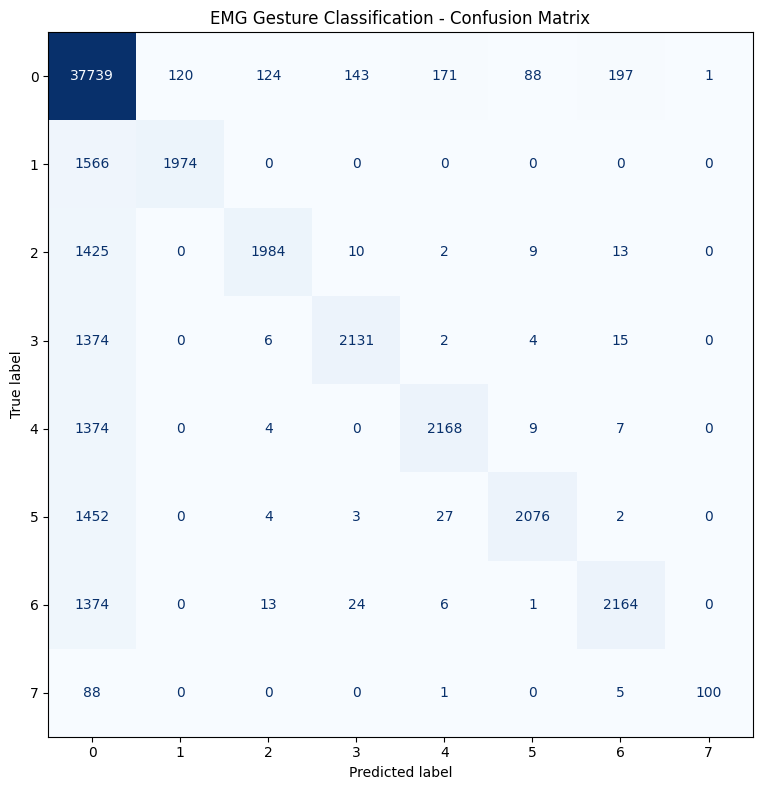


Demo Prediction
Input values:
{'channel1': -2e-05, 'channel2': 1e-05, 'channel3': 0.0, 'channel4': -7e-05, 'channel5': -3e-05, 'channel6': 1e-05, 'channel7': 0.0, 'channel8': -1e-05}
Predicted class: 0
Actual class: 0

Saved files:
- accuracy_report.txt
- confusion_matrix.png
- demo_prediction.txt
- emg_random_forest.pkl
- scaler.pkl


In [1]:
!pip -q install pandas numpy matplotlib scikit-learn scipy joblib

import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================
# 1. File path
# =========================
DATA_PATH = "EMG-data.csv"

# =========================
# 2. Load data
# =========================
print("Loading dataset...")
df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully.")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

# =========================
# 3. Define features and target
# =========================
feature_cols = [f"channel{i}" for i in range(1, 9)]
target_col = "class"

required_cols = feature_cols + [target_col]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing columns in dataset: {missing_cols}")

# Drop rows with missing values
df = df.dropna(subset=required_cols).copy()

# Convert class to int if possible
try:
    df[target_col] = df[target_col].astype(int)
except:
    pass

X = df[feature_cols]
y = df[target_col]

print("\nClass distribution:")
print(y.value_counts().sort_index())

# =========================
# 4. Optional sample for speed
# =========================
MAX_SAMPLES = 300000

if len(df) > MAX_SAMPLES:
    print(f"\nDataset is large. Taking stratified sample of {MAX_SAMPLES} rows...")
    sampled_df = (
        df.groupby(target_col, group_keys=False)
        .apply(lambda x: x.sample(
            n=max(1, int(len(x) / len(df) * MAX_SAMPLES)),
            random_state=42
        ))
        .reset_index(drop=True)
    )

    X = sampled_df[feature_cols]
    y = sampled_df[target_col]

    print("Sampled shape:", sampled_df.shape)

# =========================
# 5. Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# =========================
# 6. Normalize features
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 7. Train model
# =========================
print("\nTraining Random Forest model...")
model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

# =========================
# 8. Predict
# =========================
y_pred = model.predict(X_test_scaled)

# =========================
# 9. Accuracy and report
# =========================
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(report)

with open("accuracy_report.txt", "w", encoding="utf-8") as f:
    f.write(f"Accuracy: {accuracy:.4f}\n\n")
    f.write(report)

# =========================
# 10. Confusion Matrix
# =========================
labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("EMG Gesture Classification - Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

# =========================
# 11. Demo prediction
# =========================
sample_index = 0
sample_input = X_test.iloc[[sample_index]]
sample_input_scaled = scaler.transform(sample_input)
sample_pred = model.predict(sample_input_scaled)[0]
sample_actual = y_test.iloc[sample_index]

print("\nDemo Prediction")
print("Input values:")
print(sample_input.to_dict(orient="records")[0])
print("Predicted class:", sample_pred)
print("Actual class:", sample_actual)

with open("demo_prediction.txt", "w", encoding="utf-8") as f:
    f.write("Demo Prediction\n")
    f.write(f"Predicted class: {sample_pred}\n")
    f.write(f"Actual class: {sample_actual}\n")
    f.write(f"Input values: {sample_input.to_dict(orient='records')[0]}\n")

# =========================
# 12. Save model and scaler
# =========================
joblib.dump(model, "emg_random_forest.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nSaved files:")
print("- accuracy_report.txt")
print("- confusion_matrix.png")
print("- demo_prediction.txt")
print("- emg_random_forest.pkl")
print("- scaler.pkl")